In [1]:
%load_ext autoreload
%autoreload 2

In [6]:
import os

import joblib
import numpy as np
import pandas as pd
from psp_helper.create_windows import load_windows_and_labels
from sklearn.ensemble import (
    AdaBoostClassifier,
    AdaBoostRegressor,
    HistGradientBoostingClassifier,
    HistGradientBoostingRegressor,
    RandomForestClassifier,
    RandomForestRegressor,
)
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier, MLPRegressor

from fcl_psp.models import run_model

In [7]:
dataset_directory = r"C:\Users\user\Datasets\windows_tmp"
X_filename = "X_new_double_line_90kv_multi_fault_10k_0.05_0.005_9150.npz"
y_filename = "y_new_double_line_90kv_multi_fault_10k_0.05_0.005_9150.npz"
X_path = os.path.join(dataset_directory, X_filename)
y_path = os.path.join(dataset_directory, y_filename)

In [8]:
windows = np.load(X_path, allow_pickle=True)["X"]
labels = np.load(y_path, allow_pickle=True)["y"]

In [9]:
labels = pd.DataFrame(
    labels,
    columns=[
        "fault",
        "fault_target",
        "sc_location",
        "sc_type",
        "phase_select",
        "sample_id",
        "start_time",
    ],
)
# Set appropriate data types for the DataFrame columns
labels = labels.astype({"fault_target": "str", "sc_location": "float"})
labels.reset_index(drop=True, inplace=True)

In [10]:
labels.head()

,fault,fault_target,sc_location,sc_type,phase_select,sample_id,start_time
0,0,Line_2_3_a,19.547918,2,1,0,0.34875
1,0,Line_2_3_a,19.547918,2,1,0,0.35375
2,0,Line_2_3_a,19.547918,2,1,0,0.35875
3,0,Line_2_3_a,19.547918,2,1,0,0.36375
4,0,Line_2_3_a,19.547918,2,1,0,0.36875


In [11]:
print(f"Windows shape: {windows.shape}")
print(f"Labels shape: {labels.shape}")

Windows shape: (207506, 320, 48)
Labels shape: (207506, 7)


In [12]:
X = windows.reshape(windows.shape[0], -1)
print(f"X shape: {X.shape}")
del windows

X shape: (207506, 15360)


In [13]:
fault_target = "fault_class"

In [111]:
if fault_target == "fault_location":
    y = labels["sc_location"].astype("float")
    print("Converted fault_location values to percentage (0-1 scale).")
    # log min, max, and mean of fault_location
    print(
        f"Fault location - min: {y.min():.4f}, max: {y.max():.4f}, mean: {y.mean():.4f}"
    )
    # Keep only X and y only where "fault" is 1
    mask = labels["fault"] == 1
    X = X[mask]
    y = y[mask]
    labels = labels[mask]
    print(f"Filtered X shape: {X.shape}, y shape: {y.shape}")

elif fault_target == "fault_line":
    y = labels["fault_target"].astype("str")

Converted fault_location values to percentage (0-1 scale).
Fault location - min: 0.7362, max: 99.6230, mean: 51.3529
Filtered X shape: (1746, 15360), y shape: (1746,)


In [112]:
# Get all unique sample_ids
unique_ids = labels["sample_id"].unique()

# Split the sample_ids
train_ids, test_ids = train_test_split(unique_ids, test_size=0.2, random_state=42)

# Create boolean masks
train_mask = labels["sample_id"].isin(train_ids)
test_mask = labels["sample_id"].isin(test_ids)

In [113]:
# Apply masks to X and y
X_train, X_test = X[train_mask], X[test_mask]
del X
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (1395, 15360)
X_test shape: (351, 15360)


In [114]:
y_train, y_test = y[train_mask], y[test_mask]


print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

y_train shape: (1395,)
y_test shape: (351,)


In [115]:
y_train.head()

7     19.547918
8     19.547918
9     19.547918
10    19.547918
11    19.547918
Name: sc_location, dtype: float64

In [116]:
# Scale the data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [117]:
models_path = r"C:\Users\user\Repositories\fault-classification-localization\models"

In [129]:
import os
import re
from datetime import datetime


def get_newest_model(
    topology: str, model_name: str, window_length: str, folder: str = "."
) -> str:
    pattern = re.compile(
        rf"{re.escape(model_name)}_{re.escape(topology)}_{re.escape(window_length)}_([0-9\-]+_[0-9\-]+)\.joblib$"
    )
    newest_model = None
    newest_time = None

    for filename in os.listdir(folder):
        match = pattern.match(filename)
        if match:
            timestamp_str = match.group(1)
            try:
                timestamp = datetime.strptime(timestamp_str, "%Y-%m-%d_%H-%M-%S")
                if newest_time is None or timestamp > newest_time:
                    newest_time = timestamp
                    newest_model = os.path.join(folder, filename)
            except ValueError:
                continue  # skip malformed timestamps

    return newest_model

In [131]:
# hist_gradient_boosting_classifier_new_double_line_90kv_multi_fault_10k_0.01_2025-07-19_07-45-42.joblib
# naming_convention = (f"{model_name}_{window_length}_{timestamp}.joblib"

model = get_newest_model(
    model_name="stacking_regressor",
    topology="new_double_line_90kv_multi_fault_10k",
    window_length="0.05",
    folder=models_path,
)
print("Newest model:", model)

# Load the model
hist_boost = joblib.load(model)
hist_boost

Newest model: C:\Users\user\Repositories\fault-classification-localization\models\stacking_regressor_new_double_line_90kv_multi_fault_10k_0.05_2025-07-19_09-37-59.joblib


StackingRegressor(estimators=[('extra_trees_regressor',
                               HistGradientBoostingRegressor(random_state=42)),
                              ('mlp_regressor', MLPRegressor(random_state=42))],
                  final_estimator=LinearRegression())

In [132]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    root_mean_squared_error,
)

# Define all your models
models = {
    "hist_gradient_boosting_regressor": hist_boost,
    # "ada_boost_regressor": ada_boost_reg,
    # "mlp_regressor": mlp_regessor,
}

# Evaluate each model
for model_name, model in models.items():
    print(f"\nEvaluating model: {model_name}")

    # Predict
    y_pred = model.predict(X_test)

    # Metrics
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Print results
    print(f"  MAE:  {mae:.4f}")
    print(f"  MSE:  {mse:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  R²:   {r2:.4f}")


Evaluating model: hist_gradient_boosting_regressor
  MAE:  8.2393
  MSE:  122.5069
  RMSE: 11.0683
  R²:   0.8369


In [133]:
y_test

214      3.434257
215      3.434257
216      3.434257
217      3.434257
218      3.434257
          ...    
4404    59.480210
4405    59.480210
4406    59.480210
4407    59.480210
4408    59.480210
Name: sc_location, Length: 351, dtype: float64

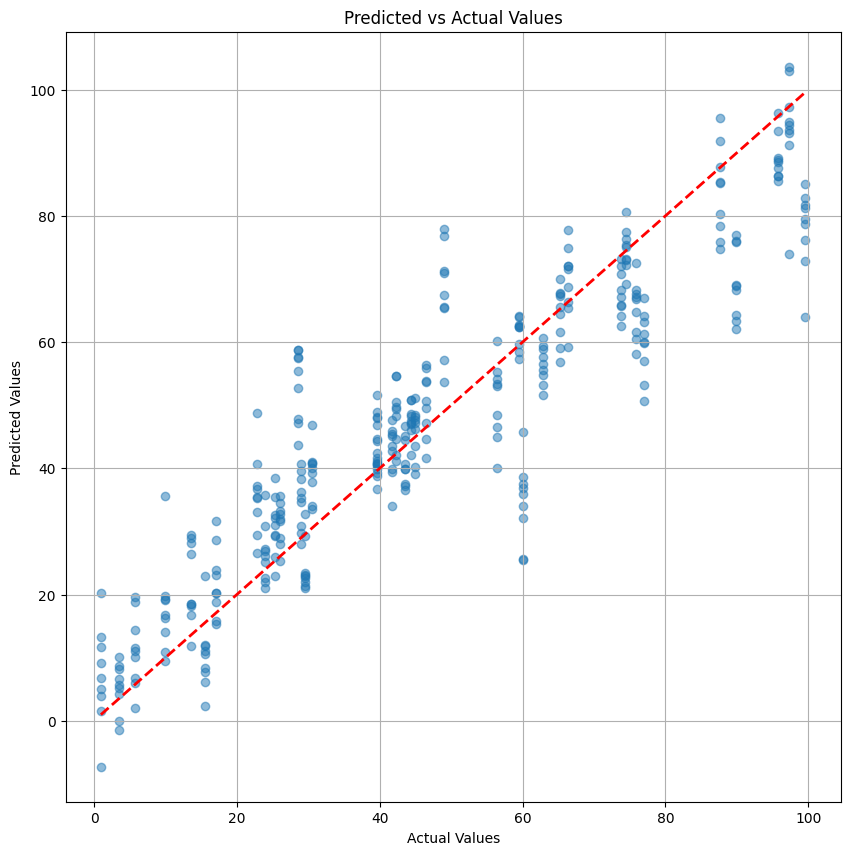

In [134]:
# Visualize the predictions vs actual values
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    lw=2,
)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

plt.title("Predicted vs Actual Values")
plt.grid()
plt.show()
# Save the predictions